# Machine learning

Il y a deux catégories principales d'apprentissage automatique : l'apprentissage supervisé et l'apprentissage non supervisé.

L'apprentissage supervisé consiste à entraîner un modèle à partir de données étiquetées, c'est-à-dire des données pour lesquelles la réponse ou la classe est connue. L'objectif est de faire des prédictions sur de nouvelles données en utilisant le modèle entraîné.

L'apprentissage non supervisé, quant à lui, consiste à entraîner un modèle à partir de données non étiquetées. L'objectif est de découvrir des structures ou des motifs cachés dans les données sans avoir de réponses préalables. Le clustering est une technique d'apprentissage non supervisé qui consiste à regrouper des données similaires en clusters ou groupes.

## Clustering

Le clustering est une technique d'apprentissage non supervisé qui consiste à regrouper des données similaires en clusters ou groupes. Il existe plusieurs algorithmes de clustering, tels que K-means, DBSCAN et Agglomerative Clustering.

Nous allons utiliser la librairie `scikit-learn` pour effectuer du clustering sur un jeu de données d'exemple. Voici un exemple de code pour effectuer du clustering avec l'algorithme K-means :

In [135]:
import pandas as pd

df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [136]:
# Sélection de colonnes entières
data = df[["Fare", "Age"]]
data.head()

,Fare,Age
0,7.2500,22.0
1,71.2833,38.0
2,7.9250,26.0
3,53.1000,35.0
4,8.0500,35.0


In [137]:
# Handle missing data
data.fillna(data.mean(), inplace=True)  # Simple mean imputation

,Fare,Age
0,7.2500,22.000000
1,71.2833,38.000000
2,7.9250,26.000000
3,53.1000,35.000000
4,8.0500,35.000000
...,...,...
886,13.0000,27.000000
887,30.0000,19.000000
888,23.4500,29.699118
889,30.0000,26.000000


In [138]:
from sklearn.preprocessing import StandardScaler

# Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data

array([[-0.50244517, -0.5924806 ],
       [ 0.78684529,  0.63878901],
       [-0.48885426, -0.2846632 ],
       ...,
       [-0.17626324,  0.        ],
       [-0.04438104, -0.2846632 ],
       [-0.49237783,  0.17706291]], shape=(891, 2))

In [139]:
# Convert back to a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
scaled_df.head()

,Fare,Age
0,-0.502445,-0.592481
1,0.786845,0.638789
2,-0.488854,-0.284663
3,0.420730,0.407926
4,-0.486337,0.407926


In [140]:
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

# K-means clustering
kmeans = KMeans(n_clusters=4)
kmeans_labels = kmeans.fit_predict(scaled_df)
kmeans_labels

array([0, 2, 2, 2, 2, 2, 1, 0, 2, 0, 0, 1, 0, 2, 0, 1, 0, 2, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 3, 2, 2, 2, 3, 2, 1, 2, 1, 2, 0, 0, 0, 2, 2, 2, 0,
       0, 2, 2, 2, 2, 0, 0, 0, 1, 2, 1, 2, 0, 2, 0, 0, 0, 2, 1, 0, 2, 2,
       2, 0, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2,
       3, 2, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2,
       1, 0, 0, 0, 0, 0, 1, 2, 3, 0, 0, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 0,
       1, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2,
       2, 1, 0, 2, 2, 2, 1, 2, 2, 0, 0, 0, 2, 1, 2, 2, 1, 0, 0, 0, 1, 0,
       2, 1, 2, 2, 2, 2, 0, 0, 0, 2, 2, 1, 2, 2, 2, 0, 0, 0, 1, 1, 2, 1,
       2, 2, 2, 2, 2, 1, 0, 0, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2,
       0, 2, 1, 2, 1, 0, 0, 0, 0, 2, 2, 2, 1, 0, 2, 2, 1, 0, 0, 2, 2, 2,
       2, 0, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 3, 1, 2, 0, 1, 2,
       2, 2, 0, 2, 1, 3, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 1, 2, 0, 0, 2, 2,
       2, 0, 1, 0, 2, 0, 2, 2, 2, 2, 2, 3, 2, 3, 2,

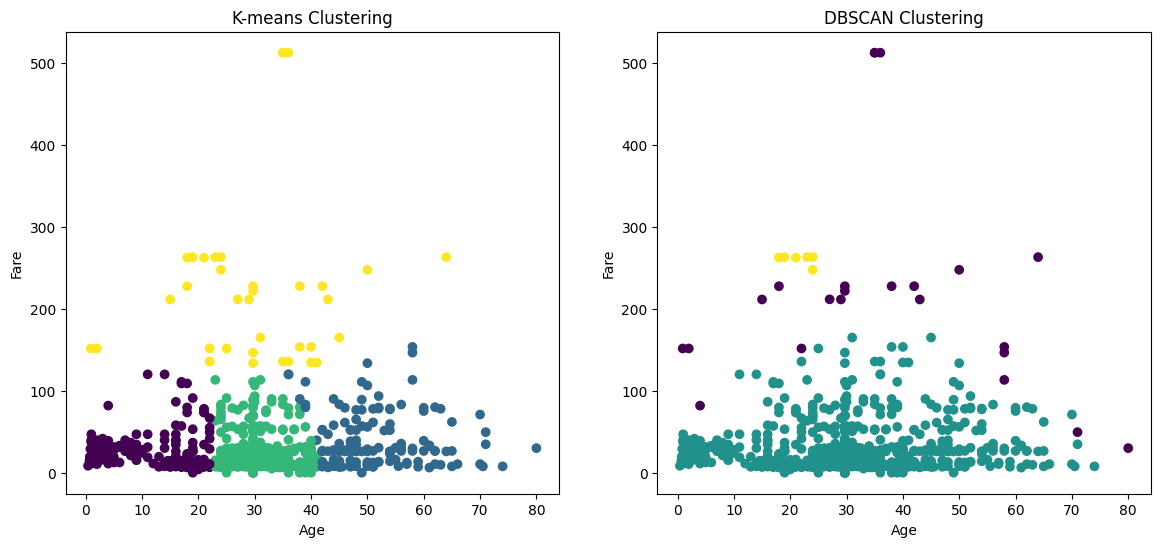

In [141]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df)

# Plotting the clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# K-means plot
ax1.scatter(data['Age'], data['Fare'], c=kmeans_labels, cmap='viridis')
ax1.set_title('K-means Clustering')
ax1.set_xlabel("Age")
ax1.set_ylabel("Fare")

# DBSCAN plot
ax2.scatter(data['Age'], data['Fare'], c=dbscan_labels, cmap='viridis')
ax2.set_title('DBSCAN Clustering')
ax2.set_xlabel("Age")
ax2.set_ylabel("Fare")

plt.show()

## Classificiation / Régression

La classification est une technique d'apprentissage supervisé qui consiste à attribuer une étiquette ou une classe à des données en fonction de leurs caractéristiques. Il existe plusieurs algorithmes de classification, tels que la régression logistique, k-plus proches voisins (k-NN), les machines à vecteurs de support (SVM) et les forêts aléatoires.

La régression, quant à elle, est une technique d'apprentissage supervisé qui consiste à prédire une valeur continue en fonction de caractéristiques d'entrée. Les algorithmes de régression incluent la régression linéaire, la régression polynomiale et les forêts aléatoires de régression.

Donc, la classification est utilisée pour prédire des catégories ou des classes, tandis que la régression est utilisée pour prédire des valeurs continues.

In [142]:
from sklearn.model_selection import train_test_split

# Remove empty values
learn_df = df.dropna(subset=["Fare", "Age", "Sex", "Survived"])
learn_df["Sex"] = learn_df["Sex"].map({"male": 0, "female": 1})

# Convert sex to numeric
X_data = learn_df[["Age", "Sex", "Fare"]]
y_data = learn_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

In [143]:
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train) # Entraînement du modèle

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [144]:
knn.score(X_test, y_test)

0.6713286713286714

In [145]:
data_to_predict = pd.DataFrame({
    'Age': [10, 40, 60, 60],
    'Sex': [1, 0, 1, 1],
    'Fare': [100, 20, 50, 500]
})
prediction = knn.predict(data_to_predict)
prediction

array([1, 0, 0, 1])